# Cell 1: Environment Setup & Imports

In [6]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Establish path alignment to project root
current_dir = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, "..")) if current_dir.endswith("notebooks") else current_dir
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"Project Anchor Root verified at: {PROJECT_ROOT}")

Project Anchor Root verified at: C:\Users\DELL\python_projects\Intrusion-Detection-System-IDS-\intrusion_detection_system


# Cell 2: Configuration & Data Load

In [7]:
with open(os.path.join(PROJECT_ROOT, "config.yaml"), "r") as f:
    config = yaml.safe_load(f)

raw_train_path = os.path.join(PROJECT_ROOT, config["data"]["raw_train_path"])
df = pd.read_csv(raw_train_path, header=None, names=config["data"]["columns"])

print(f"Raw dataset loaded successfully. Shape: {df.shape}")

Raw dataset loaded successfully. Shape: (125973, 43)


# Cell 3: Structural Overview

In [8]:
print("--- Dataset Information ---")
print(df.info())

print("\n--- Statistical Summary of Continuous Features ---")
display(df.describe().T.head(10))

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              1

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.0,0.0,0.0,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.0,0.0,0.0,7.479000e+03


# Cell 4: Class Distribution Analysis

--- Class Distribution Top 10 Profiles ---
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


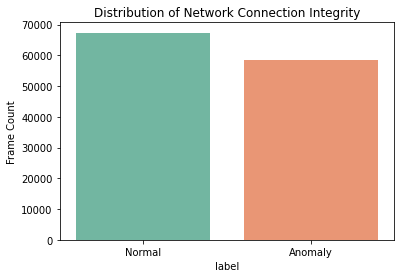

In [9]:
# Evaluate attack profiles vs normal frames
print("--- Class Distribution Top 10 Profiles ---")
label_counts = df['label'].value_counts()
print(label_counts.head(10))

# Map binary classification balance
binary_target = df['label'].apply(lambda x: "Normal" if x == "normal" else "Anomaly")
plt.figure(figsize=(6, 4))
sns.countplot(x=binary_target, palette="Set2")
plt.title("Distribution of Network Connection Integrity")
plt.ylabel("Frame Count")
plt.show()

# Cell 5: Categorical Profile Breakdown

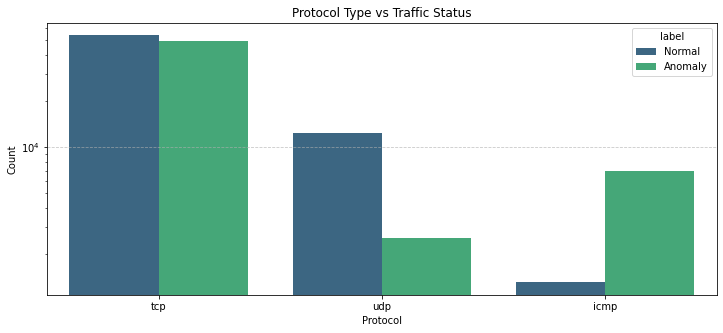

In [10]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='protocol_type', hue=binary_target, palette="viridis")
plt.title("Protocol Type vs Traffic Status")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.yscale("log")  # Using log scale to handle vast differences between TCP and UDP volumes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()